In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Review purchase data

In [2]:
df = pd.read_csv("../data/data_reviews_purchase.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
display(df.head())

,user_id,product_id,rating,product_name_x,cmt_date,shop_id,variation_x,product_quality,processed_comment
0,0,0,4,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:28:25,0,Simple,4.0,mùi hương ko bít dành cho da tùy da công da an...
1,1,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-03 12:18:12,0,Simple,5.0,mùi nhẹ dành cho da mọi loại da công_dụng rửa ...
2,2,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-05 04:57:08,0,Simple,5.0,công_dụng rửa mặt_hàng giao rất nhanh sản_phẩm...
3,3,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:07:48,0,Simple,5.0,lần thứ 2 mua sp simple thì ai cũng biết lành_...
4,4,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-31 06:21:50,0,Simple,5.0,mua lần hai rồi dùng rất thích mọi người nên m...


In [3]:
print("Togn so luong danh gia:", df.shape[0])
print("Tong so san pham", df["product_id"].unique().shape[0])
print("Tong so nguoi dung:", df["user_id"].unique().shape[0])

Togn so luong danh gia: 369099
Tong so san pham 2231
Tong so nguoi dung: 304708


In [4]:
print(df.columns)

Index(['user_id', 'product_id', 'rating', 'product_name_x', 'cmt_date',
       'shop_id', 'variation_x', 'product_quality', 'processed_comment'],
      dtype='object')


In [5]:
print(df.shape)
print(df.info())
display(df.describe().T)

(369099, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369099 entries, 0 to 369098
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_id            369099 non-null  int64  
 1   product_id         369099 non-null  int64  
 2   rating             369099 non-null  int64  
 3   product_name_x     369099 non-null  object 
 4   cmt_date           369099 non-null  object 
 5   shop_id            369099 non-null  int64  
 6   variation_x        369099 non-null  object 
 7   product_quality    369099 non-null  float64
 8   processed_comment  359418 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 25.3+ MB
None


,count,mean,std,min,25%,50%,75%,max
user_id,369099.0,147793.021338,87525.773005,0.0,71391.5,146230.0,222734.5,304707.0
product_id,369099.0,541.538408,528.220673,0.0,156.0,376.0,707.0,2235.0
rating,369099.0,4.922598,0.428819,1.0,5.0,5.0,5.0,5.0
shop_id,369099.0,256.031119,262.583847,0.0,46.0,180.0,365.0,1287.0
product_quality,369099.0,4.926283,0.412555,1.0,5.0,5.0,5.0,5.0


In [3]:
df["cmt_date"] = pd.to_datetime(df["cmt_date"])

In [7]:
# df when processed_comment is null
display(df[df["processed_comment"].isnull()])
print("Number of null comment:", len(df[df["processed_comment"].isnull()]))

,user_id,product_id,rating,product_name_x,cmt_date,shop_id,variation_x,product_quality,processed_comment
67,67,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-15 09:33:52,0,Simple,5.0,NaN
82,82,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-10 05:26:22,0,Simple,5.0,NaN
268,67,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-09-24 13:01:50,0,Simple,5.0,NaN
577,555,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2021-12-11 13:35:49,0,Simple,5.0,NaN
1278,1235,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-06-28 06:09:37,0,Simple,5.0,NaN
...,...,...,...,...,...,...,...,...,...
369017,304636,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2020-09-06 15:12:27,372,one_variation,5.0,NaN
369039,304657,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2021-08-21 14:09:03,372,one_variation,5.0,NaN
369051,304668,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2021-04-24 08:10:50,372,one_variation,5.0,NaN
369057,304672,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2021-06-05 10:08:51,372,one_variation,5.0,NaN


Number of null comment: 9681


In [8]:
sorted(df["product_quality"].unique())

[1.0, 2.0, 3.0, 4.0, 5.0]

In [65]:
# Number of low-rated reviews
len(df[(df["rating"] == 1) | (df["rating"] == 2) | (df["rating"] == 3)])

6786

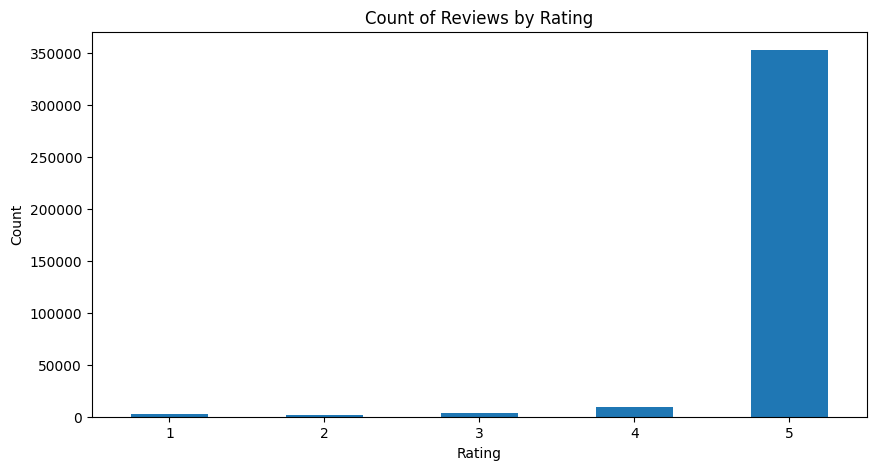

In [9]:
# plot count of reviews by rating
df["rating"].value_counts().sort_index().plot(kind="bar", figsize=(10, 5))
plt.title("Count of Reviews by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [4]:
df_sorted = df.sort_values(by=["user_id", "cmt_date"], ascending=[True, False])
display(df_sorted.head(10))

,user_id,product_id,rating,product_name_x,cmt_date,shop_id,variation_x,product_quality,processed_comment
0,0,0,4,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:28:25,0,Simple,4.0,mùi hương ko bít dành cho da tùy da công da an...
1,1,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-03 12:18:12,0,Simple,5.0,mùi nhẹ dành cho da mọi loại da công_dụng rửa ...
2,2,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-05 04:57:08,0,Simple,5.0,công_dụng rửa mặt_hàng giao rất nhanh sản_phẩm...
3,3,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:07:48,0,Simple,5.0,lần thứ 2 mua sp simple thì ai cũng biết lành_...
793,3,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-01-18 04:51:54,0,Simple,5.0,shop đóng_gói chắc_chắn có xốp chưa sử_dụng nh...
4,4,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-31 06:21:50,0,Simple,5.0,mua lần hai rồi dùng rất thích mọi người nên m...
5,5,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-07 01:50:52,0,Simple,5.0,công_dụng rua mat mùi hương kh mui dành cho da...
6,6,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-05 03:44:20,0,Simple,5.0,ko có túi chống sốc trước có sử_dụng sp này r ...
7,7,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-27 04:36:07,0,Simple,5.0,công_dụng rửa mặt mùi dành cho da nhạy_cảm_thấ...
8,8,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-26 17:38:04,0,Simple,5.0,tháng bảy năm 2010 del rey ký hợp_đồng thu âm ...


In [16]:
# tim chi muc cho cap user - item duoc comment gan day nhat
index = df_sorted.groupby(["user_id", "product_id"])["cmt_date"].idxmax()
# Tao DataFrame de luu tuong tac user - item gan nhat de tranh trung lap
df_no_dup = df_sorted.loc[index, ["user_id", "product_id", "rating", "cmt_date"]].sort_values(
    by=["user_id", "product_id"], ascending=False
)
df_no_dup

,user_id,product_id,rating,cmt_date
369098,304707,2235,5,2022-04-07 09:06:41
369097,304706,2235,5,2022-03-23 12:25:23
369096,304705,2235,5,2022-08-14 05:28:51
369095,304704,2235,5,2022-10-11 10:01:38
369093,304703,2235,5,2022-09-01 16:15:22
...,...,...,...,...
4,4,0,5,2022-12-31 06:21:50
3,3,0,5,2023-01-06 12:07:48
2,2,0,5,2023-01-05 04:57:08
1,1,0,5,2023-01-03 12:18:12


In [15]:
user_count = df_no_dup["user_id"].value_counts()
user_count[user_count >= 3]

176302    12
22708     12
13780     11
15488     10
101438     9
          ..
31968      3
141162     3
142235     3
38123      3
38086      3
Name: user_id, Length: 3952, dtype: int64

In [70]:
# Select 3952 user_id interacting with at least 3 products
list_user = df_no_dup["user_id"].value_counts()[:3952]
df_purchase = df_no_dup[df_no_dup["user_id"].isin(list_user.index)]
df_purchase

,user_id,product_id,cmt_date
368653,295796,2221,2022-12-21 06:46:28
358799,295796,1951,2022-09-19 07:23:34
357355,295796,1886,2022-11-18 06:39:16
353053,290595,1814,2022-11-12 12:03:30
350845,290595,1768,2022-12-13 13:23:02
...,...,...,...
159936,254,308,2023-01-05 03:30:48
257,254,0,2022-08-17 03:59:49
93092,40,159,2022-12-20 13:03:12
3688,40,1,2022-12-20 13:03:12


In [71]:
# sort by user_id and cmt_date descending
df_purchase = df_purchase.sort_values(by=["user_id", "cmt_date"], ascending=False)
df_purchase.head(20)

,user_id,product_id,cmt_date
368653,295796,2221,2022-12-21 06:46:28
357355,295796,1886,2022-11-18 06:39:16
358799,295796,1951,2022-09-19 07:23:34
350845,290595,1768,2022-12-13 13:23:02
353053,290595,1814,2022-11-12 12:03:30
350488,290595,1763,2022-05-13 09:39:35
348543,289116,1711,2021-10-01 04:15:25
352926,289116,1808,2021-09-20 04:03:43
364524,289116,2092,2020-04-07 12:20:56
367560,285040,2191,2022-03-30 12:26:07


In [72]:
# df_purchase.to_csv('../data/data_purchase.csv', index=False)

## Products Data

In [14]:
df_product = pd.read_csv("../data/data_product.csv")
display(df_product)

,avg_star,num_sold_time,price,variation,product_id,shop_id,product_name,brand,storage,origin,type,skin_kind,is_5_star,is_4_star,is_3_star,is_2_star,is_1_star,is_commented,is_image,num_rating,processed_description,expiry,send_from,image_path
0,4.8,185700,99000.0,one_variation,0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,18081.0,no_origin,no_type,no_skin,60700,2700,1200,640,1600,42200,37900,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,no_expiry,tp. hồ chí minh,111138057_8587034871.jpg
1,4.8,102600,99000.0,one_variation,1,0,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,9857.0,no_origin,no_type,no_skin,33200,1600,709,320,723,22700,20400,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,no_expiry,tp. hồ chí minh,111138057_8287055694.jpg
2,4.9,8100,244000.0,"['Phiên bản 2022 (80g)', 'Phiên bản 2023(100g)']",2,1,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,95.0,Việt Nam,dạng kem,no_skin,2500,97,25,8,14,886,618,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,24,hà nội,21080428_9335942418.mp4
3,4.9,3600,119000.0,one_variation,3,2,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,264.0,Việt Nam,dạng sánh,Da hỗn hợp,168,8,3,0,1,92,63,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,24,hà nội,758111427_19601743242.mp4
4,4.8,26300,9900.0,one_variation,4,3,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,987914.0,no_origin,no_type,no_skin,5700,349,150,52,61,3200,2300,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,no_expiry,hà nội,107632788_3330988133.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,5.0,872,82000.0,"['Trắng ( Trắng da ).', 'Xanh ( collagen ) .',...",2239,1288,Sữa rửa mặt Kose Softymo Nhật Bản 220g,KOSÉ,1406.0,no_origin,no_type,no_skin,264,5,1,0,0,126,121,270,sữa rửa mặt kose nhật bản best của best luôn a...,no_expiry,hà nội,294293046_5445658669.jpg
2240,5.0,43,205000.0,"['Tuýp 50ml', '200ml', '300ml', '400ml']",2240,1289,Sữa rửa mặt La Roche-Posay Effaclar chuyên dàn...,La Roche-Posay,274.0,Pháp,dạng gel,"Da mụn trứng cá, Da hỗn hợp, Dầu, Nhạy cảm",12,0,0,0,0,3,3,12,sữa rửa mặt la efaclar foaming gel sẽ giúp ngă...,24,tp. hồ chí minh,97333460_10761076591.jpg
2241,4.9,823,75000.0,"['Hồng', 'Collagen', 'White']",2241,1290,Sữa rửa mặt Kose Softymo Nhật Bản 220g,no_brand,172.0,no_origin,no_type,no_skin,210,4,2,0,2,124,106,218,sữa rửa mặt kose softymo là sản_phẩm sữa rửa m...,no_expiry,hà nội,315629668_3455178555.jpg
2242,5.0,1000,79000.0,one_variation,2242,407,Sữa Rửa Mặt Làm Sáng Da Reihaku Hatomugi Facia...,HATOMUGI,87.0,Nhật Bản,no_type,no_skin,428,7,4,0,0,192,181,439,thương_hiệu reihaku hatomugi xuất_xứ nhật bản ...,no_expiry,tp. hồ chí minh,258099521_6677227750.jpg


In [15]:
df_product.columns

Index(['avg_star', 'num_sold_time', 'price', 'variation', 'product_id',
       'shop_id', 'product_name', 'brand', 'storage', 'origin', 'type',
       'skin_kind', 'is_5_star', 'is_4_star', 'is_3_star', 'is_2_star',
       'is_1_star', 'is_commented', 'is_image', 'num_rating',
       'processed_description', 'expiry', 'send_from', 'image_path'],
      dtype='object')

In [16]:
df_product.drop(
    columns=[
        "variation",
        "shop_id",
        "storage",
        "is_5_star",
        "is_4_star",
        "is_3_star",
        "is_2_star",
        "is_1_star",
        "is_commented",
        "is_image",
        "expiry",
        "send_from",
    ],
    inplace=True,
)
df_product.head()

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg
2,4.9,8100,244000.0,2,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,Việt Nam,dạng kem,no_skin,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,21080428_9335942418.mp4
3,4.9,3600,119000.0,3,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,Việt Nam,dạng sánh,Da hỗn hợp,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,758111427_19601743242.mp4
4,4.8,26300,9900.0,4,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg


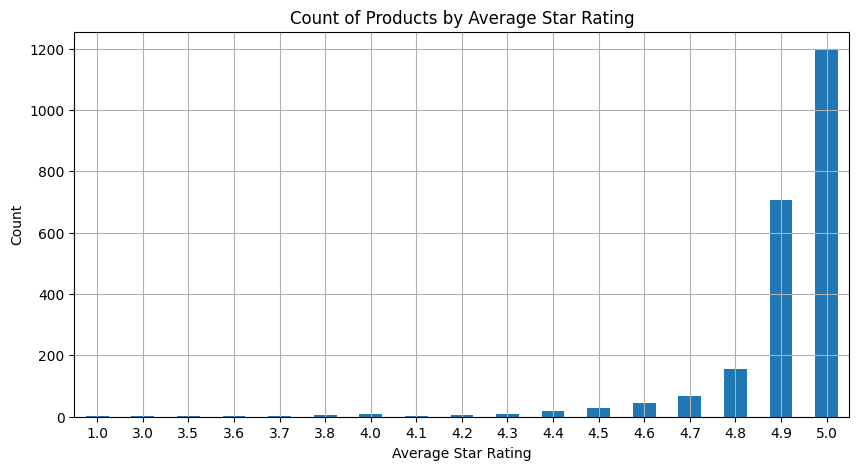

In [17]:
df_product["avg_star"].value_counts().sort_index().plot(kind="bar", figsize=(10, 5))
plt.title("Count of Products by Average Star Rating")
plt.xlabel("Average Star Rating")
plt.ylabel("Count")
plt.grid()
plt.xticks(rotation=0)
plt.show()

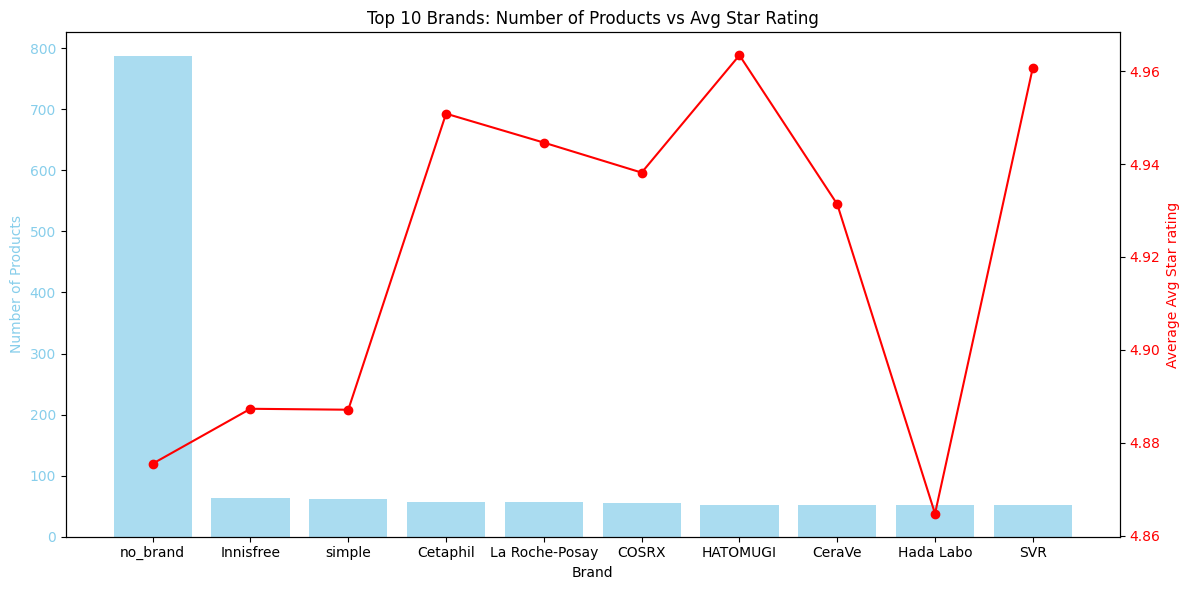

In [18]:
# Group by brand and calculate metrics
brand_metrics = (
    df_product.groupby("brand")
    .agg({"product_id": "count", "avg_star": "mean"})
    .reset_index()
)

# Sort by number of products and get top 10
top_10_brands = brand_metrics.nlargest(10, "product_id")

# Create a figure with dual axis
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Plot bars for number of products
bars = ax1.bar(
    top_10_brands["brand"], top_10_brands["product_id"], color="skyblue", alpha=0.7
)
ax1.set_xlabel("Brand")
ax1.set_ylabel("Number of Products", color="skyblue")
ax1.tick_params(axis="y", labelcolor="skyblue")

# Plot line for average popularity score
line = ax2.plot(
    top_10_brands["brand"], top_10_brands["avg_star"], color="red", marker="o"
)
ax2.set_ylabel("Average Avg Star rating", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Brands: Number of Products vs Avg Star Rating")
plt.tight_layout()
plt.show()

In [12]:
top_10_brands

,brand,product_id,avg_star
270,no_brand,787,4.875476
129,Innisfree,63,4.887302
273,simple,62,4.887097
50,Cetaphil,57,4.950877
151,La Roche-Posay,56,4.944643
47,COSRX,55,4.938182
110,HATOMUGI,52,4.963462
49,CeraVe,51,4.931373
116,Hada Labo,51,4.864706
217,SVR,51,4.960784


In [20]:
# Calculate popularity score for each product based on number of sold, number of ratings, and average star rating
df_product["normalized_sold"] = (
    df_product["num_sold_time"] / df_product["num_sold_time"].max()
)
df_product["normalized_avg_star"] = (
    df_product["avg_star"] / df_product["avg_star"].max()
)
df_product["normalized_rating"] = (
    df_product["num_rating"] / df_product["num_rating"].max()
)

sold_weight = 0.5
avg_star_weight = 0.3
rating_weight = 0.2

df_product["popularity_score"] = (
    sold_weight * df_product["normalized_sold"]
    + rating_weight * df_product["normalized_rating"]
    + avg_star_weight * df_product["normalized_avg_star"]
)

df_product.drop(
    columns=["normalized_sold", "normalized_rating", "normalized_avg_star"],
    inplace=True,
)
df_product

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path,popularity_score
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg,0.988000
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg,0.673624
2,4.9,8100,244000.0,2,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,Việt Nam,dạng kem,no_skin,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,21080428_9335942418.mp4,0.323721
3,4.9,3600,119000.0,3,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,Việt Nam,dạng sánh,Da hỗn hợp,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,758111427_19601743242.mp4,0.304232
4,4.8,26300,9900.0,4,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg,0.377700
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,5.0,872,82000.0,2239,Sữa rửa mặt Kose Softymo Nhật Bản 220g,KOSÉ,no_origin,no_type,no_skin,270,sữa rửa mặt kose nhật bản best của best luôn a...,294293046_5445658669.jpg,0.303156
2240,5.0,43,205000.0,2240,Sữa rửa mặt La Roche-Posay Effaclar chuyên dàn...,La Roche-Posay,Pháp,dạng gel,"Da mụn trứng cá, Da hỗn hợp, Dầu, Nhạy cảm",12,sữa rửa mặt la efaclar foaming gel sẽ giúp ngă...,97333460_10761076591.jpg,0.300152
2241,4.9,823,75000.0,2241,Sữa rửa mặt Kose Softymo Nhật Bản 220g,no_brand,no_origin,no_type,no_skin,218,sữa rửa mặt kose softymo là sản_phẩm sữa rửa m...,315629668_3455178555.jpg,0.296868
2242,5.0,1000,79000.0,2242,Sữa Rửa Mặt Làm Sáng Da Reihaku Hatomugi Facia...,HATOMUGI,Nhật Bản,no_type,no_skin,439,thương_hiệu reihaku hatomugi xuất_xứ nhật bản ...,258099521_6677227750.jpg,0.304006


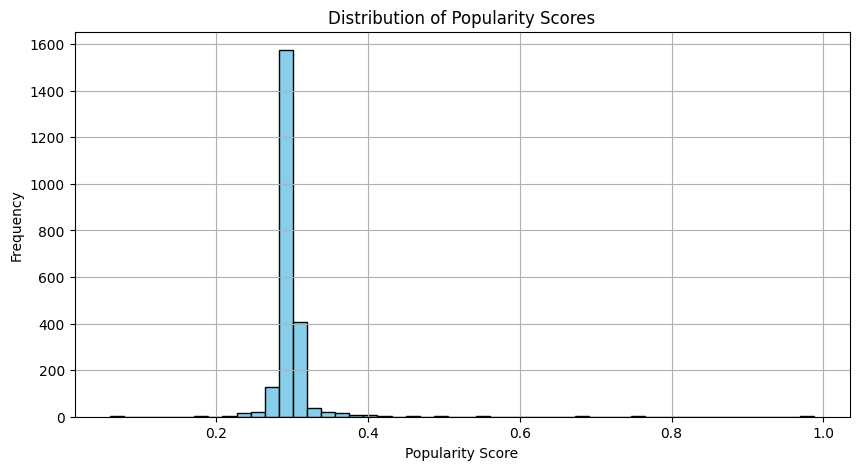

In [25]:
# Plot distribution of popularity scores
plt.figure(figsize=(10, 5))
df_product["popularity_score"].plot(
    kind="hist", bins=50, color="skyblue", edgecolor="black"
)
plt.title("Distribution of Popularity Scores")
plt.xlabel("Popularity Score")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [ ]:
# Filter products from top 10 brands with popularity score >= 0.3
top_brand_products = df_product[
    (df_product["brand"].isin(top_10_brands["brand"]))
    & (df_product["popularity_score"] >= 0.3)
]
display(top_brand_products)

# Save the filtered products to a new CSV file
top_brand_products.to_csv("../data/top_brand_products.csv", index=False)

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path,popularity_score
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg,0.988000
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg,0.673624
4,4.8,26300,9900.0,4,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg,0.377700
8,5.0,8,19900.0,8,Sữa rửa mặt giảm nám và chống tàn nhang Đông Y...,no_brand,no_origin,no_type,no_skin,2,check_mark công_dụng giúp làm mờ các mảng nám ...,102812033_21347751073.jpg,0.300028
9,5.0,2100,329000.0,9,Sữa Rửa Mặt SVR Sebiaclear Gel Moussant 400ml ...,SVR,Pháp,no_type,"Da mụn trứng cá, Mọi loại da, Da hỗn hợp",684,sữa rửa mặt svr gel mousant 40 ml gel rửa mặt ...,425554589_19931947987.jpg,0.307701
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2234,5.0,170,56000.0,2234,3 chai sữa rửa mặt con Bò Làm Trắng Da,no_brand,Trung Quốc,dạng lỏng,Mọi loại da,44,điểm nổi_bật sữa rửa mặt lyolan tẩy tế_bào chế...,27729807_515650941.jpg,0.300589
2236,5.0,136,732500.0,2236,Sữa rửa mặt Tẩy da chết Civasan Enzyme Noraxis...,no_brand,no_origin,no_type,no_skin,33,sản_phẩm an_toàn cho cả da hoàn_toàn không gây...,44469878_20733411206.jpg,0.300465
2237,5.0,733,294000.0,2237,Sữa rửa mặt Aderma,no_brand,no_origin,no_type,no_skin,299,sữa rửa mặt aderma với thành_phần lành_tính từ...,6915796_7266518732.jpg,0.302868
2240,5.0,43,205000.0,2240,Sữa rửa mặt La Roche-Posay Effaclar chuyên dàn...,La Roche-Posay,Pháp,dạng gel,"Da mụn trứng cá, Da hỗn hợp, Dầu, Nhạy cảm",12,sữa rửa mặt la efaclar foaming gel sẽ giúp ngă...,97333460_10761076591.jpg,0.300152


In [9]:
# import re

# def remove_emoji(text):
#     emoji_pattern = re.compile(
#         "["
#         "\U0001F600-\U0001F64F"  # emoticons
#         "\U0001F300-\U0001F5FF"  # symbols & pictographs
#         "\U0001F680-\U0001F6FF"  # transport & map symbols
#         "\U0001F1E0-\U0001F1FF"  # flags (iOS)
#         "\U00002700-\U000027BF"  # Dingbats
#         "\U000024C2-\U0001F251"
#         "]+", flags=re.UNICODE
#     )
#     return emoji_pattern.sub(r'', text)

# df_product['product_name'] = df_product['product_name'].apply(remove_emoji)
# df_product['brand'] = df_product['brand'].apply(remove_emoji)
# df_product.head()

In [90]:
df_product["combined_text"] = (
    df_product["product_name"]
    + " [BRAND] "
    + df_product["brand"]
    + " [ORIGIN] "
    + df_product["origin"]
    + " [TYPE] "
    + df_product["type"]
    + " [SKIN KIND] "
    + df_product["skin_kind"]
    + " [DESC] "
    + df_product["processed_description"]
)
df_product.head()

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path,popularity_score,combined_text
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg,0.988000,Sữa rửa mặt Simple lành tính sạch thoáng - cho...
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg,0.673624,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...
2,4.9,8100,244000.0,2,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,Việt Nam,dạng kem,no_skin,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,21080428_9335942418.mp4,0.323721,Sữa rửa mặt nam 30Shine phân phối chính hãng S...
3,4.9,3600,119000.0,3,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,Việt Nam,dạng sánh,Da hỗn hợp,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,758111427_19601743242.mp4,0.304232,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...
4,4.8,26300,9900.0,4,Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp Da T...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg,0.377700,Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp Da T...


In [6]:
df_product.columns

Index(['avg_star', 'num_sold_time', 'price', 'product_id', 'product_name',
       'brand', 'origin', 'type', 'skin_kind', 'num_rating',
       'processed_description', 'image_path', 'popularity_score',
       'combined_text'],
      dtype='object')

In [ ]:
# df_product.to_csv('../data/data_product_combine.csv', index=False)